In [53]:
import numpy as np
import pandas as pd

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

df = pd.read_csv("../data/bank-additional-full.csv", sep=";")
print(df.shape)
df.head()

(41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [54]:
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

print("\n'unknown' values per column:")
print((df == "unknown").sum()[lambda s: s > 0])

print("\npdays == 999:", f"{(df['pdays'] == 999).mean():.1%}")

print("\ndefault value counts:")
print(df["default"].value_counts())

Missing values: 0
Duplicate rows: 12

'unknown' values per column:
job           330
marital        80
education    1731
default      8597
housing       990
loan          990
dtype: int64

pdays == 999: 96.3%

default value counts:
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64


y
no     36548
yes     4640
Name: count, dtype: int64


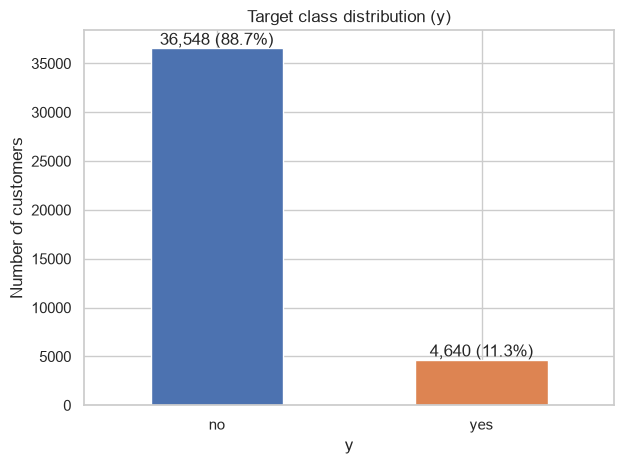

In [55]:
counts = df["y"].value_counts()
print(counts)
ax = counts.plot(kind="bar", color=["#4C72B0", "#DD8452"], rot=0)
ax.set_title("Target class distribution (y)")
ax.set_ylabel("Number of customers")
for i, v in enumerate(counts):
    ax.text(i, v, f"{v:,} ({v/len(df):.1%})", ha="center", va="bottom")
plt.tight_layout()
plt.savefig("figures/class_balance.png", dpi=150)
plt.show()


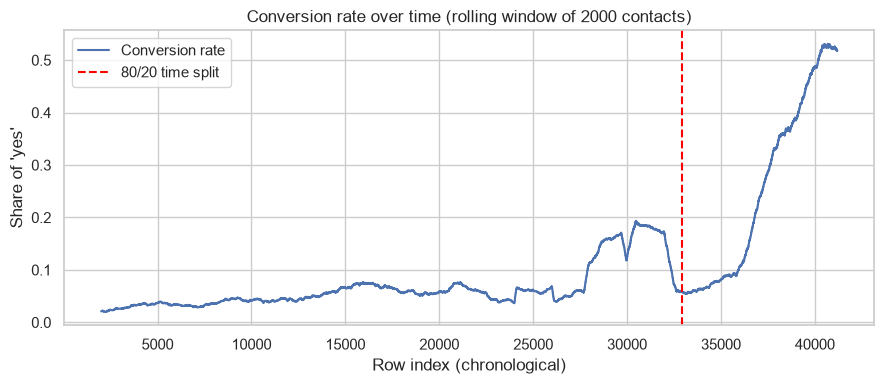

In [56]:
window = 2000
rolling_rate = (df["y"] == "yes").astype(int).rolling(window).mean()

ax = rolling_rate.plot(figsize=(9, 4), label="Conversion rate")
cut = int(len(df) * 0.8)
ax.axvline(cut, color="red", ls="--", label="80/20 time split")
ax.set_title(f"Conversion rate over time (rolling window of {window} contacts)")
ax.set_xlabel("Row index (chronological)")
ax.set_ylabel("Share of 'yes'")
ax.legend()
plt.tight_layout()
plt.savefig("figures/conversion_over_time.png", dpi=150)
plt.show()

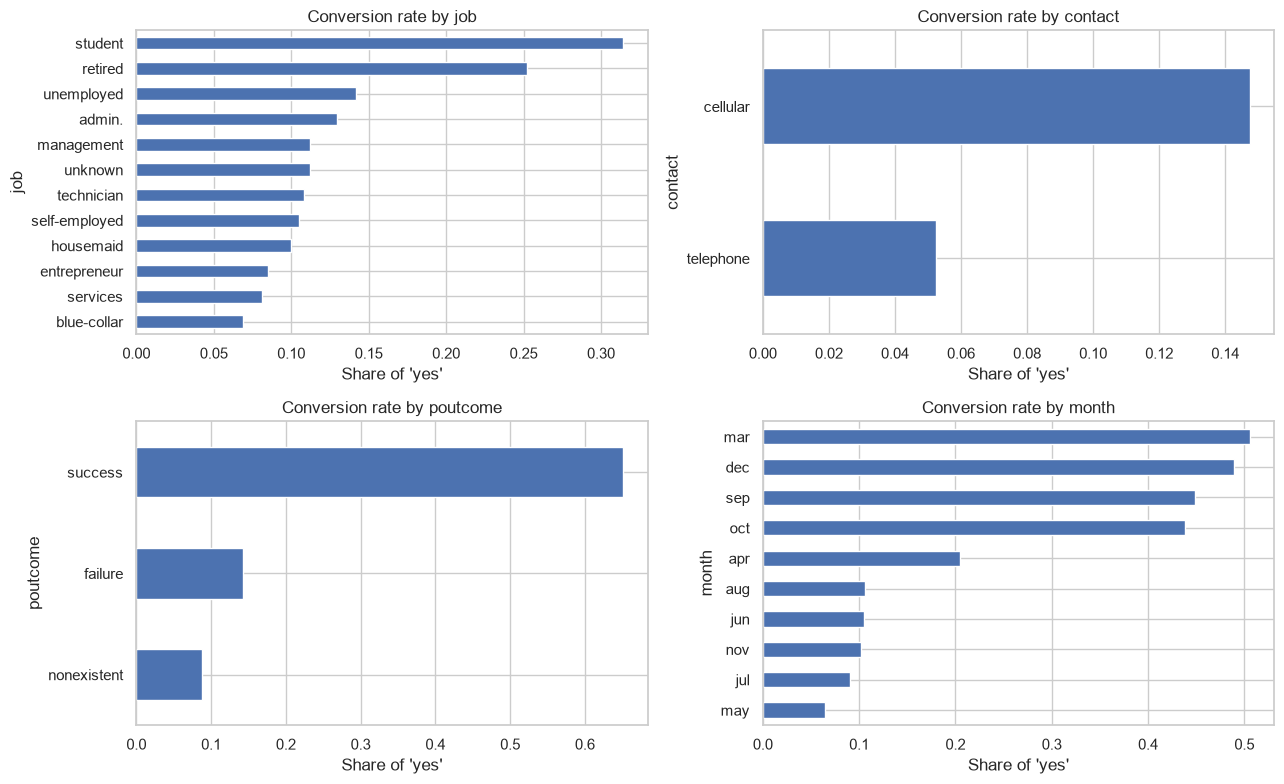

In [57]:
cat_cols_eda = ["job", "contact", "poutcome", "month"]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, col in zip(axes.ravel(), cat_cols_eda):
    rate = df.groupby(col)["y"].apply(lambda s: (s == "yes").mean()).sort_values()
    rate.plot(kind="barh", ax=ax, color="#4C72B0")
    ax.set_title(f"Conversion rate by {col}")
    ax.set_xlabel("Share of 'yes'")
plt.tight_layout()
plt.savefig("figures/conversion_by_category.png", dpi=150)
plt.show()

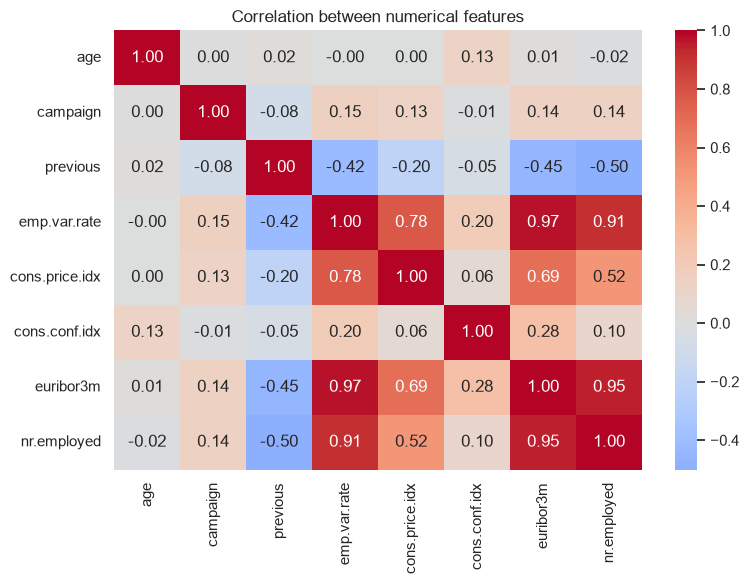

In [58]:
num_cols_eda = ["age", "campaign", "previous", "emp.var.rate", "cons.price.idx",
                "cons.conf.idx", "euribor3m", "nr.employed"]

plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols_eda].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation between numerical features")
plt.tight_layout()
plt.savefig("figures/correlation_heatmap.png", dpi=150)
plt.show()

In [59]:
data = df.drop_duplicates().reset_index(drop=True)
data = data.drop(columns=["duration"])
print(data.shape)

(41176, 20)


In [60]:
data.to_csv("../data/cleaned_data.csv", index=False)
print("Saved ../data/cleaned_data.csv")

Saved ../data/cleaned_data.csv
